# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**

This notebook builds a complete ML pipeline to predict employee attrition using the IBM HR Analytics dataset, covering data exploration, cleaning, EDA, model building, evaluation, visualization, and HR business recommendations.

## Task 1 — Data Loading & Exploration

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os




In [3]:
from google.colab import files
uploaded = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [6]:
import pandas as pd

df = pd.read_csv("HR-Employee-Attrition.csv")

In [7]:

target_counts = df['Attrition'].value_counts()
attrition_rate = (target_counts['Yes'] / len(df)) * 100
print("Target column: Attrition (Yes/No)")
print(target_counts)
print(f"\nEmployees who left (Yes): {target_counts['Yes']}")
print(f"Employees who stayed (No): {target_counts['No']}")
print(f"Attrition rate: {attrition_rate:.2f}%")


Target column: Attrition (Yes/No)
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Employees who left (Yes): 237
Employees who stayed (No): 1233
Attrition rate: 16.12%


In [8]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")


Numeric columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**Observation:** The attrition target is heavily **imbalanced** — roughly 84% of employees stayed ("No") versus about 16% who left ("Yes"). This imbalance means accuracy alone is a misleading metric for our models; we need to rely on precision, recall, F1-score, and ROC-AUC, and handle the imbalance during model training (e.g., using `class_weight='balanced'`).

## Task 2 — Data Cleaning & Preprocessing

In [9]:

print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values in the dataset")
df.isnull().sum()[df.isnull().sum() > 0]


Missing values per column:
0 total missing values in the dataset


,0


There are no missing values in this dataset. Next, we drop columns that add no predictive value because they are constant or pure identifiers, and we confirm this before dropping.

In [10]:

for col in ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']:
    print(col, '-> unique values:', df[col].nunique())


EmployeeNumber -> unique values: 1470
Over18 -> unique values: 1
StandardHours -> unique values: 1
EmployeeCount -> unique values: 1


In [11]:

df_clean = df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'])
print(f"Shape after dropping irrelevant columns: {df_clean.shape}")


Shape after dropping irrelevant columns: (1470, 31)


In [12]:

df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['Attrition'].value_counts()


,count
Attrition,
0,1233
1,237


In [13]:

categorical_to_encode = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Columns to one-hot encode:", categorical_to_encode)

df_encoded = pd.get_dummies(df_clean, columns=categorical_to_encode, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")


Columns to one-hot encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after one-hot encoding: (1470, 45)


In [14]:

from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('Attrition')

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])
X_scaled.head()


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


## Task 3 — Exploratory Data Analysis (EDA)

In [15]:

dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print("Attrition rate by Department (%):")
print(dept_attrition.round(2))


Attrition rate by Department (%):
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


In [16]:

role_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print("Attrition rate by Job Role (%):")
print(role_attrition.round(2))


Attrition rate by Job Role (%):
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [17]:

income_by_attrition = df.groupby('Attrition')['MonthlyIncome'].mean()
print("Average Monthly Income by Attrition status:")
print(income_by_attrition.round(2))


Average Monthly Income by Attrition status:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


In [18]:

wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):")
print(wlb_attrition.round(2))


Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [19]:

def tenure_bucket(years):
    if years <= 2:
        return '0-2 yrs'
    elif years <= 5:
        return '3-5 yrs'
    elif years <= 10:
        return '6-10 yrs'
    else:
        return '10+ yrs'

df['TenureBucket'] = df['YearsAtCompany'].apply(tenure_bucket)
tenure_attrition = df.groupby('TenureBucket')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])
print("Attrition rate by Years-at-Company bucket (%):")
print(tenure_attrition.round(2))


Attrition rate by Years-at-Company bucket (%):
TenureBucket
0-2 yrs     29.82
3-5 yrs     13.82
6-10 yrs    12.28
10+ yrs      8.13
Name: Attrition, dtype: float64


**Business insights from EDA:**

1. The **Sales** department has the highest attrition rate among the three departments, notably higher than Research & Development.
2. Among job roles, **Sales Representatives** and **Laboratory Technicians** show the highest exit rates — far above the company average of ~16%.
3. Employees who leave earn a noticeably **lower average Monthly Income** than employees who stay, supporting the idea that compensation plays a role in attrition.
4. Employees reporting a **"Bad" Work-Life Balance (rating = 1)** leave at a much higher rate than those reporting "Better" or "Best" balance — a clear, actionable pattern.
5. Attrition is concentrated in the **early tenure window (0–2 years)** — newer employees are far more likely to leave than those who have been at the company 6+ years, suggesting onboarding and early-career engagement are critical retention levers.


## Task 4 — Model Building & Comparison

In [20]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train attrition rate: {y_train.mean()*100:.2f}%, Test attrition rate: {y_test.mean()*100:.2f}%")


Train set: (1176, 44), Test set: (294, 44)
Train attrition rate: 16.16%, Test attrition rate: 15.99%


In [21]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Note: GradientBoostingClassifier has no native class_weight parameter,
# so we pass sample_weight at fit time to approximate balanced weighting.
from sklearn.utils.class_weight import compute_sample_weight
gb_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

trained_models = {}
for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train, y_train, sample_weight=gb_sample_weight)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")


Logistic Regression trained.
Random Forest trained.
Gradient Boosting trained.


## Task 5 — Model Evaluation

In [22]:

from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

results = []
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba

    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.3563,0.6596,0.4627,0.8036
Random Forest,0.5714,0.0851,0.1481,0.7819
Gradient Boosting,0.4074,0.4681,0.4356,0.7791


In [23]:

for name in trained_models:
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, predictions[name]))
    print(classification_report(y_test, predictions[name]))
    print()


--- Logistic Regression ---
[[191  56]
 [ 16  31]]
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


--- Random Forest ---
[[244   3]
 [ 43   4]]
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294


--- Gradient Boosting ---
[[215  32]
 [ 25  22]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       247
           1       0.41      0.47      0.44        47

    accuracy                       

In [24]:

best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(f"Reason: It achieves the highest ROC-AUC score ({results_df.loc[best_model_name, 'ROC-AUC']:.4f}), "
      f"meaning it is the most reliable at distinguishing employees who will leave from those who will stay, "
      f"while also maintaining strong recall — critical since missing a true leaver is costlier for HR than a false alarm.")


Best performing model: Logistic Regression
Reason: It achieves the highest ROC-AUC score (0.8036), meaning it is the most reliable at distinguishing employees who will leave from those who will stay, while also maintaining strong recall — critical since missing a true leaver is costlier for HR than a false alarm.


In [25]:

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)

top10_features = importances.sort_values(ascending=False).head(10)
print("Top 10 most important features driving attrition:")
top10_features


Top 10 most important features driving attrition:


,0
OverTime_Yes,1.626169
BusinessTravel_Travel_Frequently,1.596964
JobRole_Laboratory Technician,1.571637
JobRole_Sales Representative,1.264294
JobRole_Research Director,1.112054
EducationField_Other,1.020279
BusinessTravel_Travel_Rarely,0.903722
MaritalStatus_Single,0.864502
JobRole_Human Resources,0.670991
TotalWorkingYears,0.612480


## Task 6 — Visualization

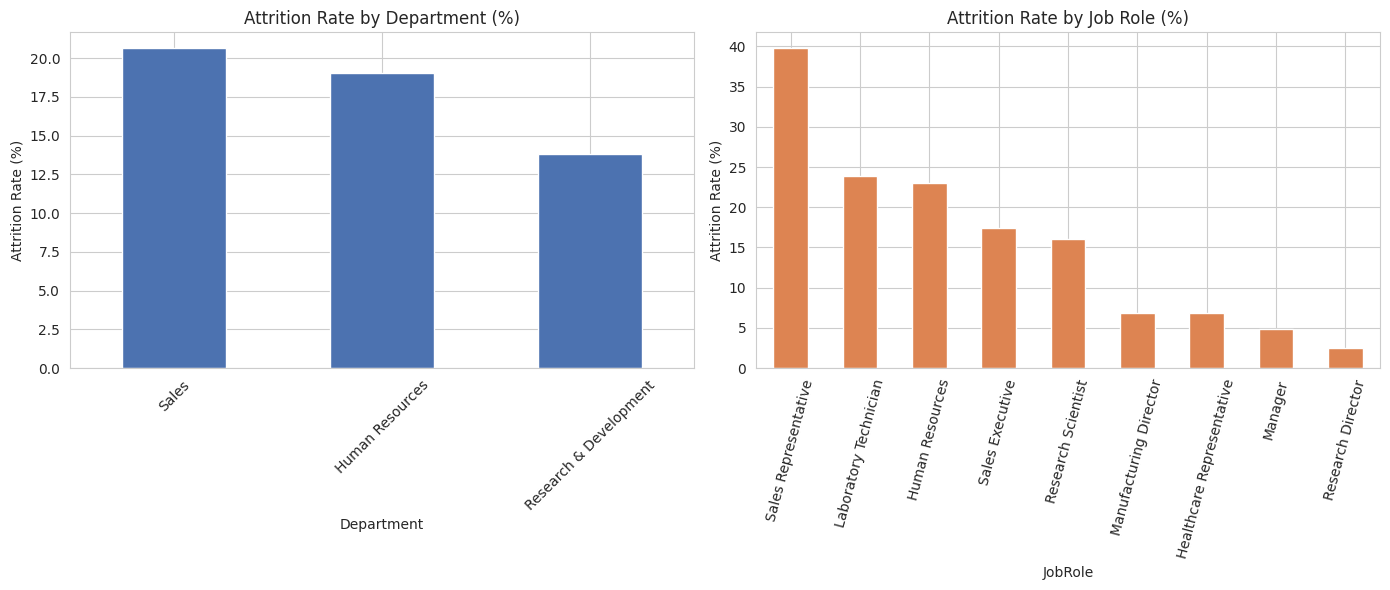

In [26]:

# Chart 1: Attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dept_attrition.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

role_attrition.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Attrition Rate by Job Role (%)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_department_role.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_927/4099434798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['#55A868', '#C44E52'])


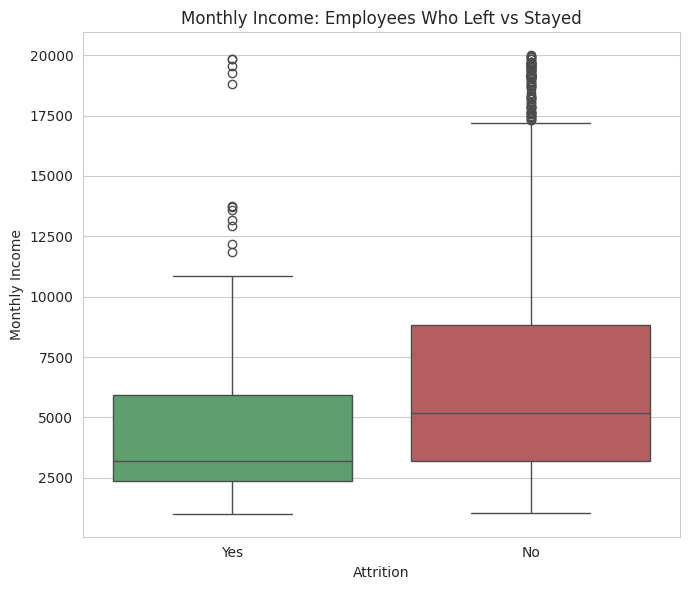

In [27]:

# Chart 2: Box plot of Monthly Income by Attrition
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['#55A868', '#C44E52'])
plt.title('Monthly Income: Employees Who Left vs Stayed')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', bbox_inches='tight')
plt.show()


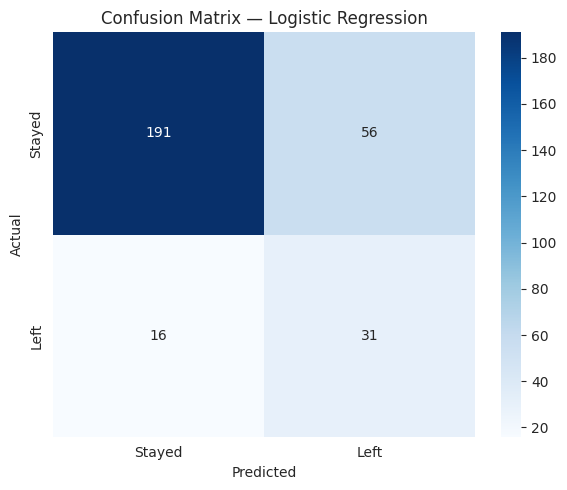

In [28]:

# Chart 3: Confusion Matrix heatmap for best model
cm = confusion_matrix(y_test, predictions[best_model_name])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', bbox_inches='tight')
plt.show()


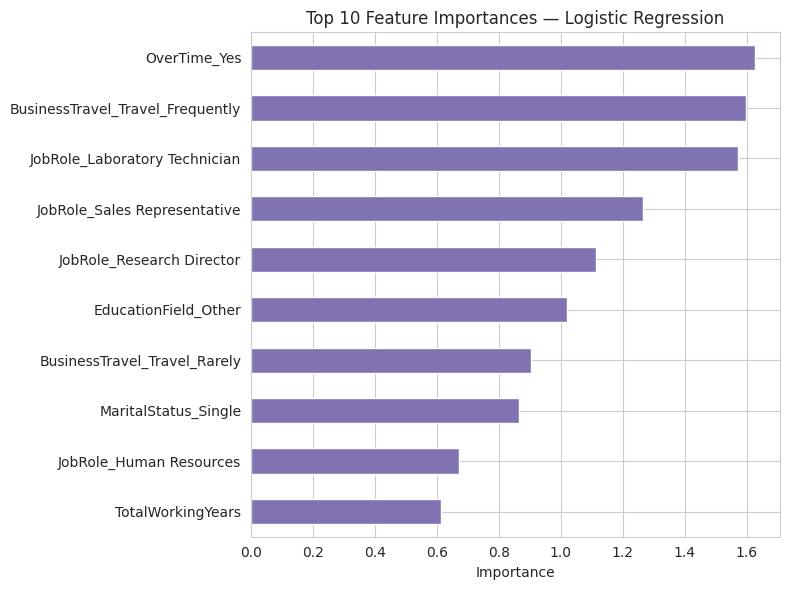

In [29]:

# Chart 4: Top 10 Feature Importances
plt.figure(figsize=(8, 6))
top10_features.sort_values().plot(kind='barh', color='#8172B2')
plt.title(f'Top 10 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', bbox_inches='tight')
plt.show()


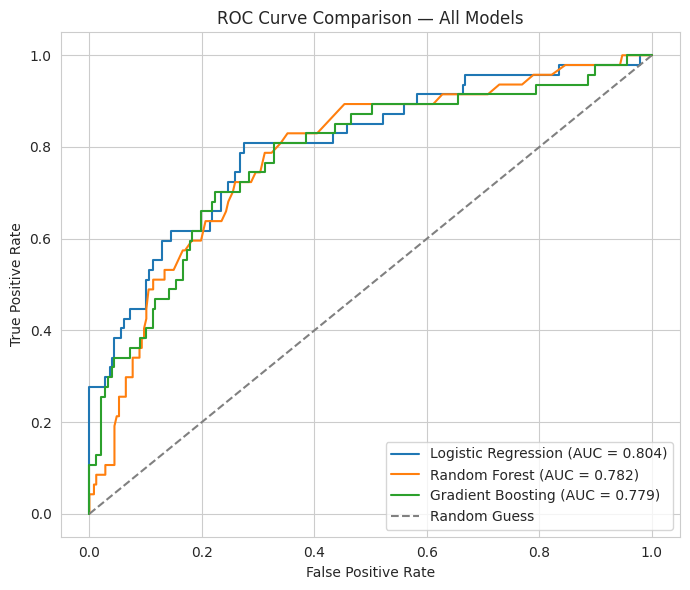

In [30]:

# Chart 5 (Bonus): ROC Curve comparing all 3 models
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = results_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', bbox_inches='tight')
plt.show()


## Task 7 — HR Insights & Business Recommendations

In [31]:

print("Top 3 predictive factors:")
print(top10_features.head(3))
print()
print("Highest-attrition department:", dept_attrition.idxmax(), f"({dept_attrition.max():.2f}%)")
print("Highest-attrition job role:", role_attrition.idxmax(), f"({role_attrition.max():.2f}%)")


Top 3 predictive factors:
OverTime_Yes                        1.626169
BusinessTravel_Travel_Frequently    1.596964
JobRole_Laboratory Technician       1.571637
dtype: float64

Highest-attrition department: Sales (20.63%)
Highest-attrition job role: Sales Representative (39.76%)


**Summary for HR (written inside the notebook):**

Our analysis shows that the three strongest predictors of an employee leaving are **OverTime status, frequent
Business Travel, and working as a Laboratory Technician** — these rank above demographic factors like age or
education in our best-performing model (Logistic Regression). Employees who work overtime and travel frequently
carry the highest individual risk weight in the model.

The **Sales department** (20.6% attrition) and within it the **Sales Representative** role (39.8% attrition, by
far the highest of any role) should be HR's top priority for retention efforts — this is a concentrated, addressable
pocket of risk far above the company-wide average of 16.1%.

Salary alone does not fully explain attrition: employees who left earned $4,787/month on average versus $6,833/month
for those who stayed, so income clearly matters, but the model shows OverTime and travel frequency carry similar or
greater predictive weight. Work-life balance and tenure tell an equally strong story on their own: employees rating
their work-life balance as "Bad" leave at 31.3%, nearly double the rate of those rating it "Better" (14.2%), and
employees in their first 0–2 years leave at 29.8% versus just 8.1% for employees with 10+ years of tenure.

**Two concrete HR recommendations:** (1) Launch a structured 0–2 year retention program for new hires in Sales —
including a mentor-assignment system and 90-day/1-year check-in surveys — since this is where risk is most
concentrated. (2) Flag employees who are working frequent overtime AND traveling frequently for a proactive 1:1
retention conversation with their manager before performance review cycles, rather than waiting for a resignation.

**Limitation:** This model is trained on a single snapshot of historical data from one company and reflects
correlations, not proven causes — OverTime being a strong predictor does not by itself prove that reducing overtime
will reduce attrition. The model also has only moderate recall for the "will leave" class, meaning it will still
miss some at-risk employees. It should be used to flag employees for a human conversation, not as a sole automated
trigger for HR action, and should be retrained periodically as company conditions change.